### **Data Exploration**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [6]:
dataset = pd.read_csv('pokemon.csv')
dataset.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


Fazer descricao do dataset... e pq escolhemos.


| Column | Description |
| :--- | :--- |
| **Name** | The name of the Pokemon |
| **Type 1** | Primary type (e.g., Fire, Water, Grass) |
| **Type 2** | Secondary type, if any |
| **Total** | Sum of all base stats |
| **HP** | Hit points / Health of the Pokemon |
| **Attack** | Physical attack power |
| **Defense** | Physical defense strength |
| **Sp. Atk** | Special attack power |
| **Sp. Def** | Special defense strength |
| **Speed** | Speed stat |
| **Generation** | The generation of Pokemon (1-8) |
| **Legendary** | Boolean flag indicating if the Pokemon is legendary |

In [4]:

plt.rcParams.update({
    "figure.figsize": (7, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11
})

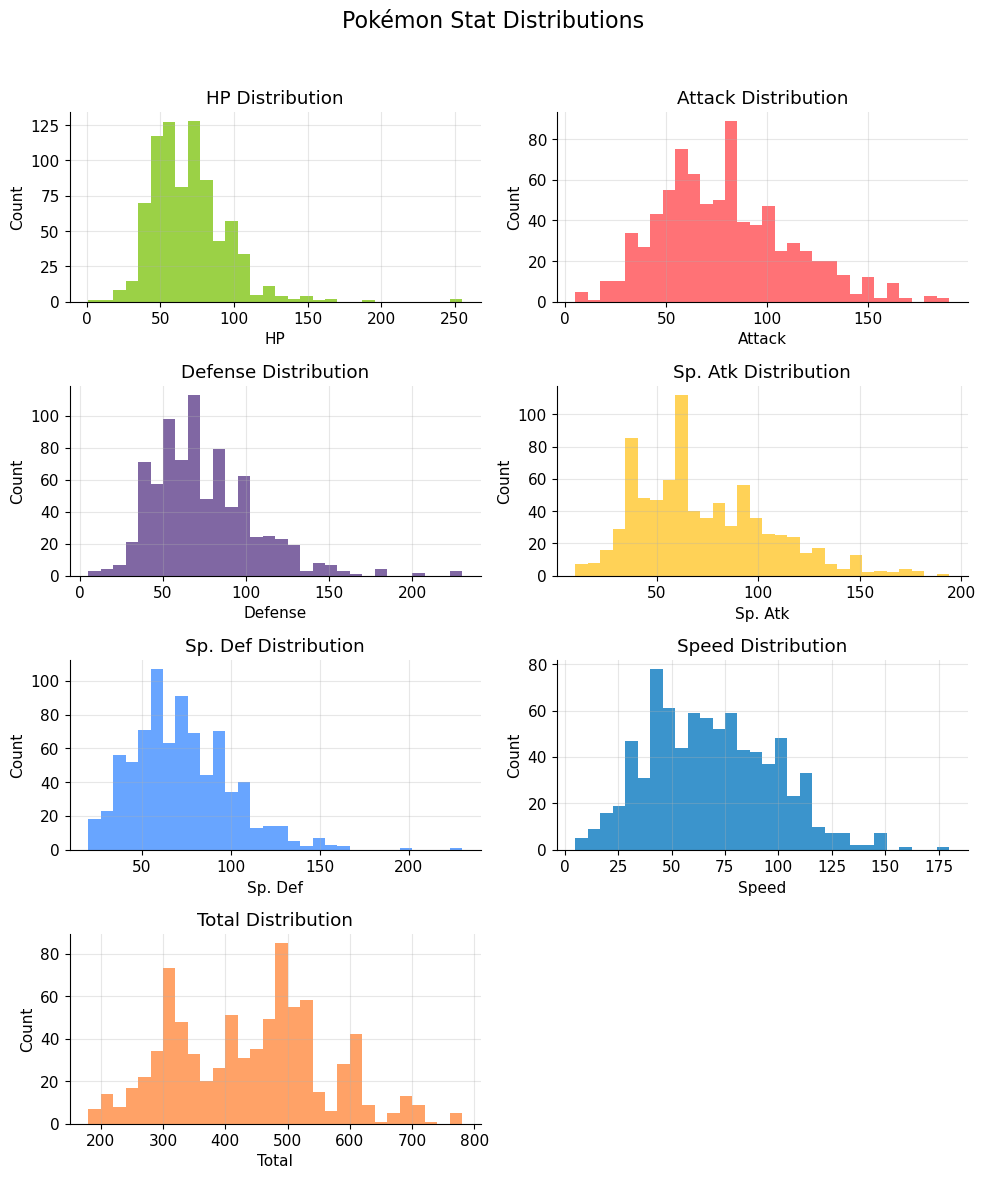

In [8]:
stats = [
    "HP",
    "Attack",
    "Defense",
    "Sp. Atk",
    "Sp. Def",
    "Speed",
    "Total"
]


stat_colors = {
    "HP": "#8AC926",        # green
    "Attack": "#FF595E",    # red
    "Defense": "#6A4C93",   # purple
    "Sp. Atk": "#FFCA3A",    # yellow
    "Sp. Def": "#4D96FF",    # blue
    "Speed": "#1982C4",     # darker blue
    "Total": "#FF924C"      # orange
}

n_stats = len(stats)
n_cols = 2
n_rows = int(np.ceil(n_stats / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 3 * n_rows))
axes = axes.flatten()

# ----------------------------
# Plot histograms
# ----------------------------
for i, stat in enumerate(stats):
    axes[i].hist(
        dataset[stat],
        bins=30,
        color=stat_colors[stat],
        alpha=0.85
    )
    axes[i].set_title(f"{stat} Distribution")
    axes[i].set_xlabel(stat)
    axes[i].set_ylabel("Count")

# ----------------------------
# Hide unused axes
# ----------------------------
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# ----------------------------
# Aesthetic cleanup
# ----------------------------
for ax in axes[:n_stats]:
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Pokémon Stat Distributions", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

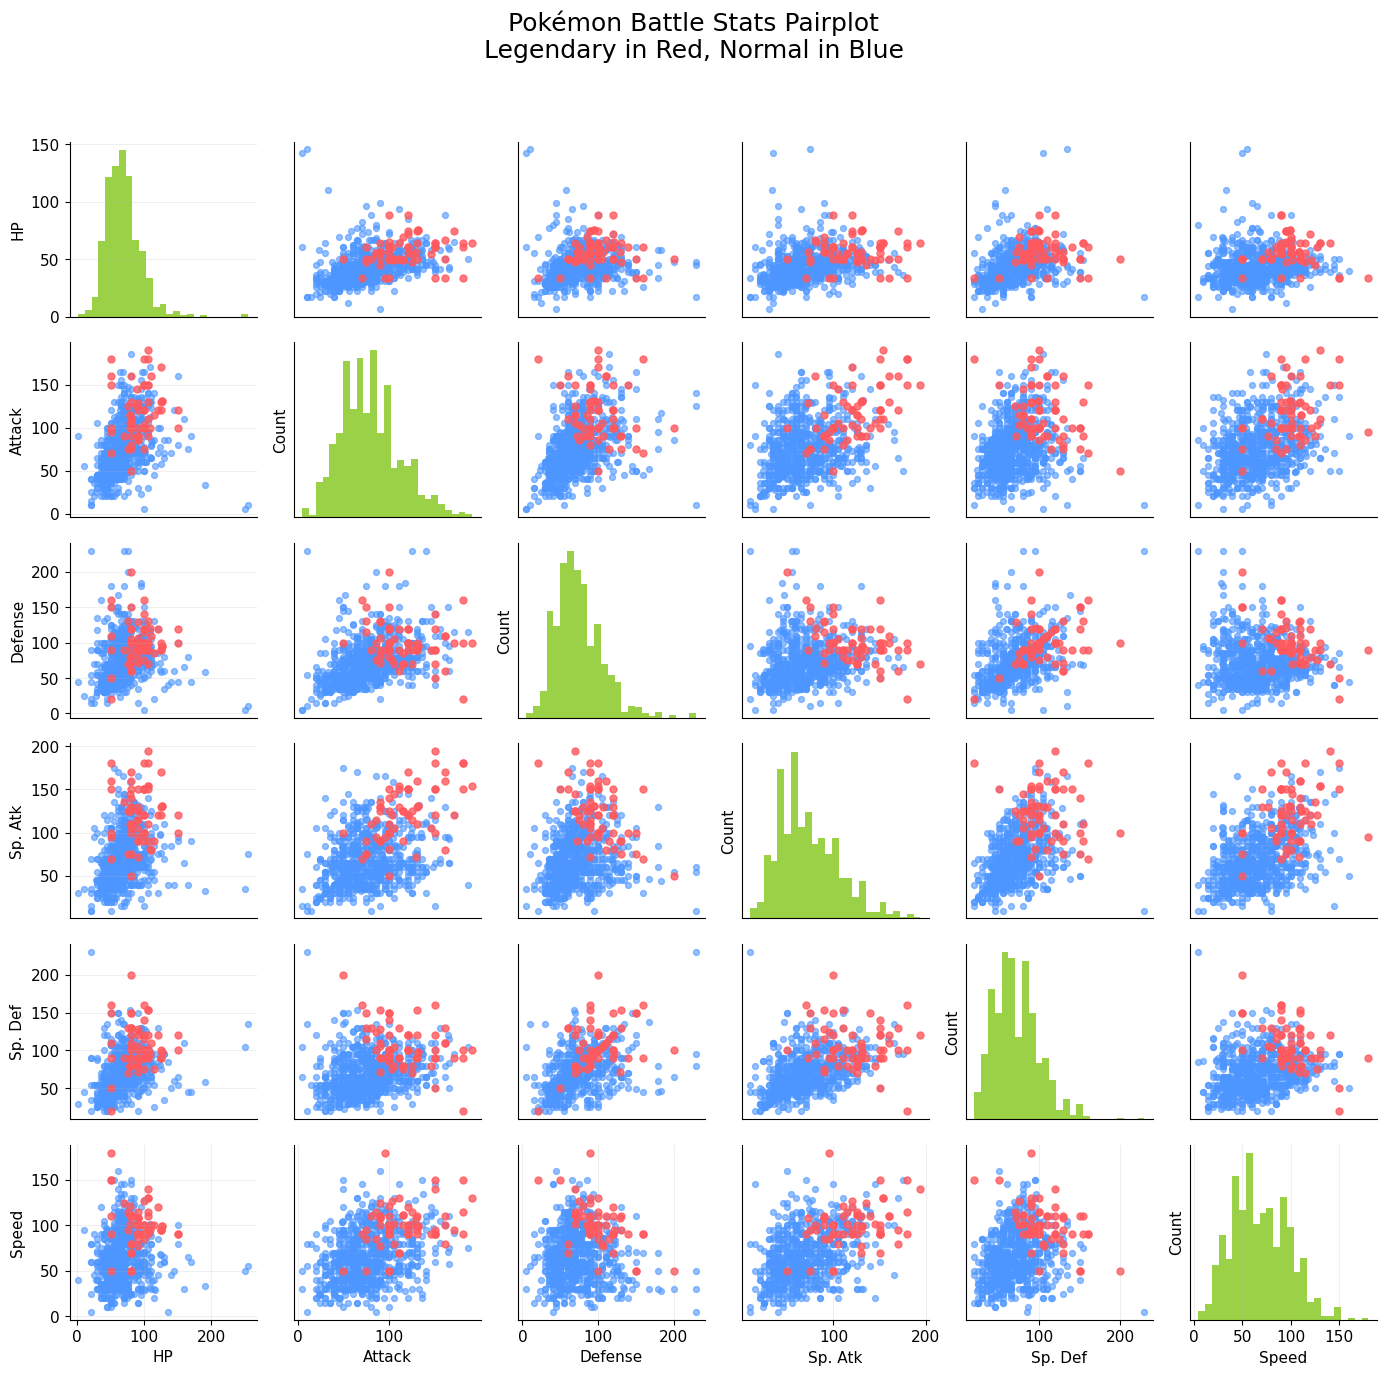

In [11]:
stats = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]

n = len(stats)

# Colors
color_normal = "#4D96FF"     # blue
color_legend = "#FF595E"     # red

fig, axes = plt.subplots(n, n, figsize=(14, 14))

for i in range(n):
    for j in range(n):
        ax = axes[i, j]

        if i == j:
            # Diagonal: histogram
            ax.hist(
                dataset[stats[i]],
                bins=25,
                color="#8AC926",
                alpha=0.85
            )
            ax.set_ylabel("Count")

        else:
            # Off-diagonal: scatter
            ax.scatter(
                dataset.loc[~dataset["Legendary"], stats[j]],
                dataset.loc[~dataset["Legendary"], stats[i]],
                s=18,
                alpha=0.6,
                color=color_normal
            )

            ax.scatter(
                dataset.loc[dataset["Legendary"], stats[j]],
                dataset.loc[dataset["Legendary"], stats[i]],
                s=25,
                alpha=0.8,
                color=color_legend
            )

        # Labeling only outer axes
        if i == n - 1:
            ax.set_xlabel(stats[j])
        else:
            ax.set_xticks([])

        if j == 0:
            ax.set_ylabel(stats[i])
        else:
            ax.set_yticks([])

        # Clean look
        ax.grid(True, alpha=0.2)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

# Global title
fig.suptitle(
    "Pokémon Battle Stats Pairplot\nLegendary in Red, Normal in Blue",
    fontsize=18
)

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

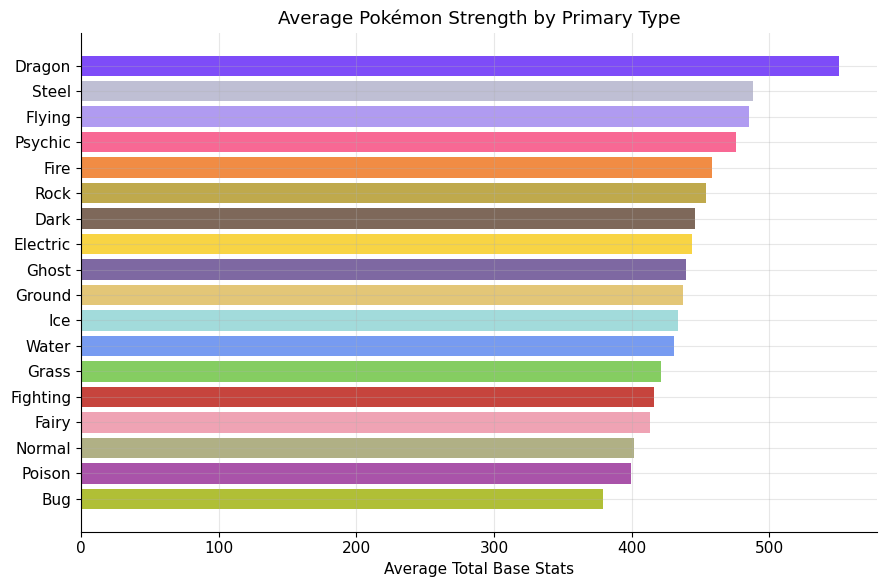

In [13]:

type_means = (
    dataset
    .groupby("Type 1")["Total"]
    .mean()
    .sort_values()
)

# Pokémon-inspired type color map
type_colors = {
    "Grass": "#78C850",
    "Fire": "#F08030",
    "Water": "#6890F0",
    "Electric": "#F8D030",
    "Psychic": "#F85888",
    "Ice": "#98D8D8",
    "Dragon": "#7038F8",
    "Dark": "#705848",
    "Fairy": "#EE99AC",
    "Normal": "#A8A878",
    "Fighting": "#C03028",
    "Flying": "#A890F0",
    "Poison": "#A040A0",
    "Ground": "#E0C068",
    "Rock": "#B8A038",
    "Bug": "#A8B820",
    "Ghost": "#705898",
    "Steel": "#B8B8D0"
}

# Match colors to types (fallback gray if unknown)
bar_colors = [type_colors.get(t, "#999999") for t in type_means.index]

plt.figure(figsize=(9, 6))
plt.barh(type_means.index, type_means.values, color=bar_colors, alpha=0.9)

plt.xlabel("Average Total Base Stats")
plt.title("Average Pokémon Strength by Primary Type")

# Clean look
ax = plt.gca()
ax.grid(True, axis="x", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()